# Fig4e-f: 3D liver cell reconstruction based EMCellFound model

Information:

Dataset ID: jrc_mus-liver-6

Source: HHMI Janelia OpenOrganelle

Sample: Liver tissue from a 10-week-old male leptin-deficient
B6.Cg-Lepob/J (ob/ob) mouse on a C57BL/6J genetic background.

Native voxel size: 8 × 8 × 8 nm (z, y, x).

Native array shape: 8,501 × 8,050 × 8,000 voxels (z, y, x).

Physical extent: 68,008 × 64,400 × 64,000 nm (z, y, x).

This experiment evaluated sparse-annotation adaptation within a single
specimen, volume, and acquisition session; it was not designed as an
evaluation of cross-specimen or cross-volume generalization.

We randomly selected three images extracted from the xy, xz, and yz planes for training, three for validation, and three for testing.

- Training slices: x=5000, y=2000, z=3000
- Validation slices: x=7500, y=6500, z=4000
- Testing slices: x=4000, y=5000, z=6000


train datset
'''
jrc_mus_liver-6_part_5000
jrc_mus_liver-6_part_y_2000
jrc_mus_liver-6_part_z_3000
'''

val dataset
'''
jrc_mus_liver-6_part_7500
jrc_mus_liver-6_part_y_6500
jrc_mus_liver-6_part_z_4000
'''

test dataset
'''
jrc_mus_liver-6_part_z_6000
jrc_mus_liver-6_part_4000
jrc_mus_liver-6_part_y_5000
'''


The organelles to be segmented.
0 background: [0, 0, 0]
1 ER: [128, 128, 0]
2 mito: [128, 0, 128]
3 LD: [123, 95, 213]
4 Nu: [14, 159, 38]


Download the model.

In [ ]:
import os
from huggingface_hub import snapshot_download
from pathlib import Path
BASE_DIR = Path.cwd().resolve().parent

local_model_dir = (BASE_DIR / "models")
snapshot_download(repo_id="Zeyu0102/EMCFsys_models", repo_type="model",
                  local_dir=local_model_dir,
                  local_dir_use_symlinks=False, resume_download=True,
                  max_workers=1)


First Download the dataset and the 3D vEM volume.

In this demo, we use part of this dataset, because full-size vEM is too large (>500 GB)

Partition volume (1998x2136x4250) of the original size. 

The data (12GB) can be download from huggingface link (https://huggingface.co/datasets/Zeyu0102/Obese2_Liver_6_Dataset)

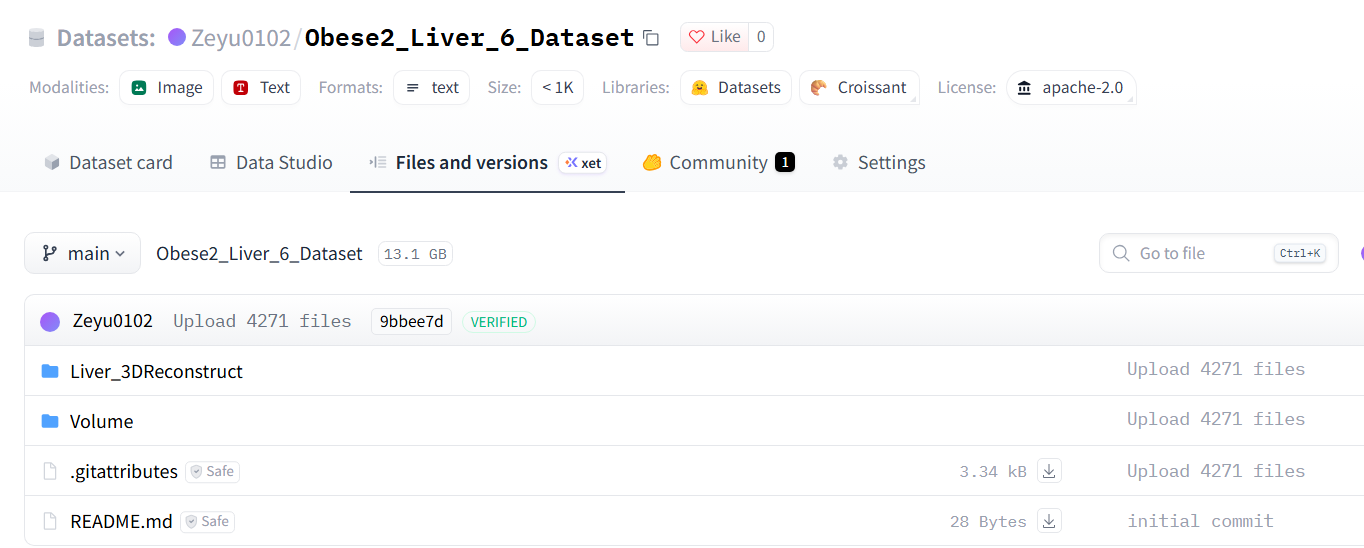

In [ ]:
import os
from huggingface_hub import snapshot_download
import pathlib
BASE_DIR = pathlib.Path.cwd().resolve().parent

data_dir = (BASE_DIR / "demo" / "datasets_temp" / "Obese2_Liver_6_Dataset")

snapshot_download(repo_id="Zeyu0102/Obese2_Liver_6_Dataset", repo_type="dataset",
                  local_dir=data_dir,
                  local_dir_use_symlinks=False, 
                  resume_download=True,
                  )

print("Obese2_Liver_6_Dataset 3D Reconstruction Dataset downloaded successfully.")

c:\Users\YZY\miniconda3\envs\EMCF_napari\Lib\site-packages\huggingface_hub\utils\_validators.py:189: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(
c:\Users\YZY\miniconda3\envs\EMCF_napari\Lib\site-packages\huggingface_hub\utils\_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching ... files: 0it [00:00, ?it/s]

HTTP Error 504 thrown while requesting HEAD https://huggingface.co/datasets/Zeyu0102/Obese2_Liver_6_Dataset/resolve/9bbee7d9535efa3391b3ecc350b1f96d6295abea/Volume/jrc_mus_liver_6_0941.png
Retrying in 1s [Retry 1/5].
HTTP Error 504 thrown while requesting HEAD https://huggingface.co/datasets/Zeyu0102/Obese2_Liver_6_Dataset/resolve/9bbee7d9535efa3391b3ecc350b1f96d6295abea/Volume/jrc_mus_liver_6_0942.png
Retrying in 1s [Retry 1/5].
HTTP Error 504 thrown while requesting HEAD https://huggingface.co/datasets/Zeyu0102/Obese2_Liver_6_Dataset/resolve/9bbee7d9535efa3391b3ecc350b1f96d6295abea/Volume/jrc_mus_liver_6_0944.png
Retrying in 1s [Retry 1/5].
HTTP Error 504 thrown while requesting HEAD https://huggingface.co/datasets/Zeyu0102/Obese2_Liver_6_Dataset/resolve/9bbee7d9535efa3391b3ecc350b1f96d6295abea/Volume/jrc_mus_liver_6_0944.png
Retrying in 2s [Retry 2/5].
HTTP Error 504 thrown while requesting HEAD https://huggingface.co/datasets/Zeyu0102/Obese2_Liver_6_Dataset/resolve/9bbee7d9535efa33

In [2]:
from mmengine import Config
import pathlib
import sys
# Get the base directory of the project, which is the parent directory of the current working directory
BASE_DIR = pathlib.Path.cwd().resolve().parent
print(f"BASE_DIR: {BASE_DIR}")

# set the root directory of the project to the module search path
root = pathlib.Path(BASE_DIR)
# add the root directory to the module search path
sys.path.insert(0, str(root))


cfg_path = BASE_DIR / 'src'/ 'thirdParty' / 'mmsegmentation' /"configs" / "Liver_seg" / "ViT_Finetune.py"
model_path = BASE_DIR / "models" / "MAE_backbone_mmbackend.pth"
data_root = BASE_DIR / "demo" / "datasets_temp" / "Obese2_Liver_6_Dataset" / "Liver_3DReconstruct"
work_dir = BASE_DIR / "demo" / "logs" / "LiverSeg3DReconstruct"

# validate the existence of the config and model files
print(f"BASE_DIR: {BASE_DIR}")
print(f"cfg exists: {cfg_path.exists()}")
print(f"model exists: {model_path.exists()}")
assert cfg_path.exists(), f"Config not found: {cfg_path}"
assert model_path.exists(), f"Checkpoint not found: {model_path}"


cfg = Config.fromfile(cfg_path)
# set the path to the pretrained model from the huggingface hub, 
# you can change it to your own path if you have downloaded the model to a different location
# models are named as "xxxx_backbone_mmbackend.pth" in the huggingface hub
cfg.load_from = str(model_path)
# set the path to the dataset where the dataset is unzipped, 
# you can change it to your own path if you have downloaded the dataset to a different location
cfg.data_root = str(data_root)


from configs.register_models.runtime import set_data_root
set_data_root(cfg, cfg.data_root)
# set the working directory to save logs and models
cfg.work_dir = str(work_dir)

# check the batch size of the training dataloader, if it is too large, you can reduce it to avoid out of memory error
# batch size=8 need ~ 24GB GPU
cfg.train_dataloader.batch_size = 8

from mmengine.runner import Runner
runner = Runner.from_cfg(cfg)
# start training
runner.train()

BASE_DIR: D:\napari_EMCF\EMCFsys\emcfsys
BASE_DIR: D:\napari_EMCF\EMCFsys\emcfsys
cfg exists: True
model exists: True
09/27 13:13:20 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: win32
    Python: 3.11.10 | packaged by Anaconda, Inc. | (main, Oct  3 2024, 07:22:26) [MSC v.1929 64 bit (AMD64)]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 1506182555
    GPU 0: NVIDIA GeForce RTX 3090
    CUDA_HOME: C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.8
    NVCC: Cuda compilation tools, release 11.8, V11.8.89
    MSVC: n/a, reason: fileno
    PyTorch: 2.5.1+cu118
    PyTorch compiling details: PyTorch built with:
  - C++ Version: 201703
  - MSVC 192930154
  - Intel(R) oneAPI Math Kernel Library Version 2024.2.2-Product Build 20240823 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v3.5.3 (Git Hash 66f0cb9eb66affd2da3bf5f8d897376f04aae6af)
  - OpenMP 2019
  - LAPACK is en

c:\Users\YZY\miniconda3\envs\EMCF_napari\Lib\site-packages\mmengine\utils\manager.py:113: UserWarning: <class 'mmseg.visualization.local_visualizer.SegLocalVisualizer'> instance named of visualizer has been created, the method `get_instance` should not accept any other arguments
  warnings.warn(
D:\napari_EMCF\EMCFsys\emcfsys\src\thirdParty\mmsegmentation\mmseg\models\losses\cross_entropy_loss.py:255: UserWarning: Default ``avg_non_ignore`` is False, if you would like to ignore the certain label and average loss over non-ignore labels, which is the same with PyTorch official cross_entropy, set ``avg_non_ignore=True``.
  warnings.warn(


09/27 13:13:24 - mmengine - INFO - Distributed training is not used, all SyncBatchNorm (SyncBN) layers in the model will be automatically reverted to BatchNormXd layers if they are used.
09/27 13:13:24 - mmengine - INFO - Hooks will be executed in the following order:
before_run:
(VERY_HIGH   ) RuntimeInfoHook                    
(BELOW_NORMAL) LoggerHook                         
 -------------------- 
before_train:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(VERY_LOW    ) CheckpointHook                     
 -------------------- 
before_train_epoch:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(NORMAL      ) DistSamplerSeedHook                
 -------------------- 
before_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
 -------------------- 
after_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                

D:\napari_EMCF\EMCFsys\emcfsys\src\thirdParty\mmsegmentation\mmseg\engine\hooks\visualization_hook.py:60: UserWarning: The draw is False, it means that the hook for visualization will not take effect. The results will NOT be visualized or stored.
  warnings.warn('The draw is False, it means that the '


09/27 13:13:27 - mmengine - INFO - paramwise_options -- backbone.timm_model.model.cls_token:lr=1e-05
09/27 13:13:27 - mmengine - INFO - paramwise_options -- backbone.timm_model.model.cls_token:weight_decay=0.01
09/27 13:13:27 - mmengine - INFO - paramwise_options -- backbone.timm_model.model.cls_token:lr_mult=0.1
09/27 13:13:27 - mmengine - INFO - paramwise_options -- backbone.timm_model.model.pos_embed:lr=1e-05
09/27 13:13:27 - mmengine - INFO - paramwise_options -- backbone.timm_model.model.pos_embed:weight_decay=0.01
09/27 13:13:27 - mmengine - INFO - paramwise_options -- backbone.timm_model.model.pos_embed:lr_mult=0.1
09/27 13:13:27 - mmengine - INFO - paramwise_options -- backbone.timm_model.model.patch_embed.proj.weight:lr=1e-05
09/27 13:13:27 - mmengine - INFO - paramwise_options -- backbone.timm_model.model.patch_embed.proj.weight:weight_decay=0.01
09/27 13:13:27 - mmengine - INFO - paramwise_options -- backbone.timm_model.model.patch_embed.proj.weight:lr_mult=0.1
09/27 13:13:2

c:\Users\YZY\miniconda3\envs\EMCF_napari\Lib\site-packages\mmengine\runner\checkpoint.py:347: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(filename,

The model and loaded state dict do not match exactly

unexpected key in source state_dict: classifier.weight, classifier.bias, decoder.mask_token, decoder.decoder_pos_embed, decoder.decoder_embed.weight, decoder.decoder_embed.bias, decoder.decoder_blocks.0.norm1.weight, decoder.decoder_blocks.0.norm1.bias, decoder.decoder_blocks.0.attn.qkv.weight, decoder.decoder_blocks.0.attn.qkv.bias, decoder.decoder_blocks.0.attn.proj.weight, decoder.decoder_blocks.0.attn.proj.bias, decoder.decoder_blocks.0.norm2.weight, decoder.decoder_blocks.0.norm2.bias, decoder.decoder_blocks.0.mlp.fc1.weight, decoder.decoder_blocks.0.mlp.fc1.bias, decoder.decoder_blocks.0.mlp.fc2.weight, decoder.decoder_blocks.0.mlp.fc2.bias, decoder.decoder_blocks.1.norm1.weight, decoder.decoder_blocks.1.norm1.bias, decoder.decoder_blocks.1.attn.qkv.weight, decoder.decoder_blocks.1.attn.qkv.bias, decoder.decoder_blocks.1.attn.proj.weight, decoder.decoder_blocks.1.attn.proj.bias, decoder.decoder_blocks.1.norm2.weight, decoder.d

EncoderDecoder(
  (data_preprocessor): SegDataPreProcessor()
  (backbone): TIMMBackbone(
    (timm_model): FeatureGetterNet(
      (model): VisionTransformer(
        (patch_embed): PatchEmbed(
          (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
          (norm): Identity()
        )
        (pos_drop): Dropout(p=0.0, inplace=False)
        (patch_drop): Identity()
        (norm_pre): Identity()
        (blocks): Sequential(
          (0): Block(
            (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
            (attn): Attention(
              (qkv): Linear(in_features=768, out_features=2304, bias=True)
              (q_norm): Identity()
              (k_norm): Identity()
              (attn_drop): Dropout(p=0.0, inplace=False)
              (norm): Identity()
              (proj): Linear(in_features=768, out_features=768, bias=True)
              (proj_drop): Dropout(p=0.0, inplace=False)
            )
            (ls1): Identity()
            

Loads checkpoint by local backend from path: D:\napari_EMCF\EMCFsys\emcfsys\demo\logs\LiverSeg3DReconstruct\best_mIoU_iter_2000.pth
✅ Model loaded successfully!
Classes info: ('background', 'ER', 'Mito', 'LD', 'Nu')


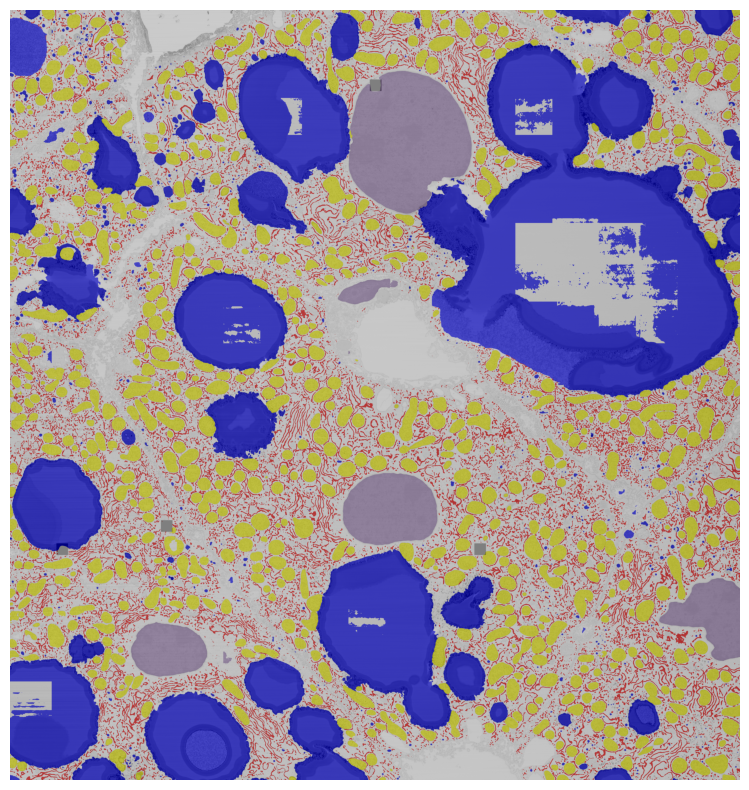

In [ ]:
import pathlib
import sys
import torch
import cv2
import matplotlib.pyplot as plt
from mmengine import Config
from mmseg.apis import init_model, inference_model, show_result_pyplot

# ===================== Base Path Dir=====================
# BASE_DIR = pathlib.Path(r"Fill your absolute path").resolve()
BASE_DIR = pathlib.Path.cwd().resolve().parent

sys.path.insert(0, str(BASE_DIR))

cfg_path = str(BASE_DIR / "demo" / "logs" / "LiverSeg3DReconstruct" / "ViT_Finetune.py")
# get the path to the best checkpoint,
# using search to find the best checkpoint in the work_dir
for file in (BASE_DIR / "demo" / "logs" / "LiverSeg3DReconstruct").glob("best_mIoU_iter_*.pth"):
    ckpt_path = str(file)
    break
# =================================================================

# 1. load the config and model
cfg = Config.fromfile(cfg_path)
# when inference, 
# we can set the mode to "slide" and specify the crop size and stride 
# for sliding window inference
cfg.test_cfg.mode = "slide"
# when training, we set crop_size as (512, 512).
# When inference, we can set crop_size as (512, 512) or (1024, 1024) to speed up inference.
cfg.test_cfg.crop_size = (1024,1024)
cfg.test_cfg.stride = (800, 800)


model = init_model(cfg, ckpt_path, device="cuda:0")
print("✅ Model loaded successfully!")
print(f"Classes info: {model.dataset_meta['classes']}")

# 2. inference a single image
img_path = str(BASE_DIR  / "demo"/ "datasets_temp" / "Obese2_Liver_6_Dataset" / "Liver_3DReconstruct" / "image" / "jrc_mus_liver-6_part_z_6000.tif")
img = cv2.imread(img_path)

with torch.no_grad():
    result = inference_model(model, img)

# visualize the result
vis_img = show_result_pyplot(model, img, result, opacity=0.5, show=False)

plt.figure(figsize=(10,10))
plt.imshow(vis_img)
plt.axis('off')
plt.show()

Since lipid droplets (LD) and nuclei (Nu) can span a very large spatial extent, small sliding windows cannot fully cover these structures, which introduces holes inside the segmented regions.

Two strategies can mitigate this problem: training separate models for small organelles (ER and mitochondria) versus large structures (Nu and LD), or applying hole-filling post-processing. We opted to train dedicated models for small and large organelles, and we adopt this latter strategy in our demo.

See below:

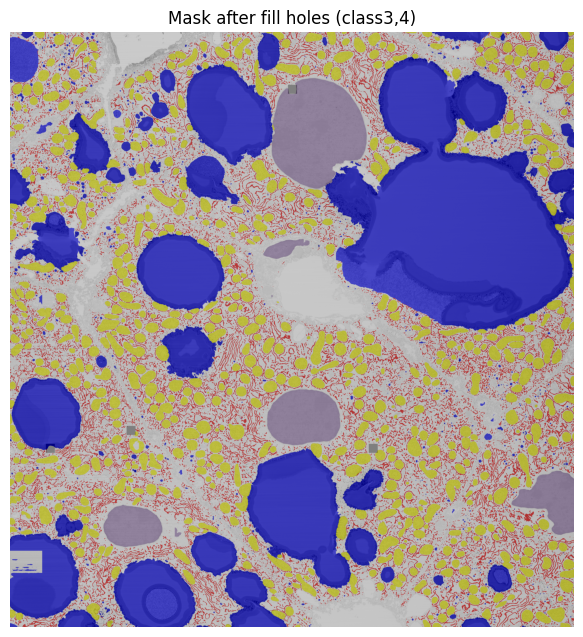

In [ ]:
from mmseg.apis import fill_holes_for_classes
pred_mask_np = result.pred_sem_seg.data[0].cpu().numpy()
# fill holes for classes 3 and 4 (too large Nu and LD) in the segmentation mask
pred_mask_filled_np = fill_holes_for_classes(pred_mask_np, target_classes=[3,4])


result.pred_sem_seg.data[0] = torch.from_numpy(pred_mask_filled_np)
# Visualization
vis_img = show_result_pyplot(model, img, result, opacity=0.5, show=False)
plt.figure(figsize=(16, 16))
plt.subplot(1,2,1)
plt.imshow(vis_img)
plt.title("Mask after fill holes (class3,4)")
plt.axis("off")
plt.show()

We have successfully trained a 2D segmentation model for ER, mitochondria, nucleus (Nu), and lipid droplets (LD).

 To reconstruct the 3D structure of the volumetric dataset, we perform inference slice-by-slice along the z-axis of the volume to obtain 2D segmentation predictions for each slice.

These 2D slice masks can then be imported into Amira, Avizo, or Arivis for 3D visualization.

Full dataset can be downloaded from: https://www.ebi.ac.uk/empiar/EMPIAR-10791/
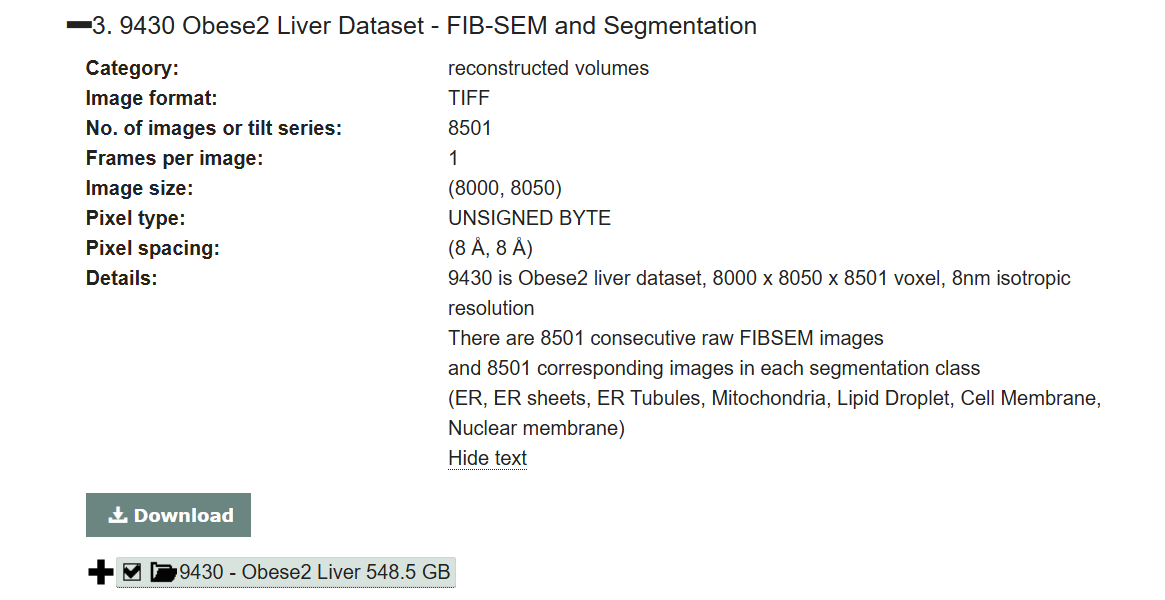


#### 2D slice inference for 3D reconstruction

In [ ]:
import pathlib
import sys
import torch
import cv2
import matplotlib.pyplot as plt
import numpy as np
# Get the base directory of the project, which is the parent directory of the current working directory
BASE_DIR = pathlib.Path.cwd().resolve().parent
print(f"BASE_DIR: {BASE_DIR}")
# set the root directory of the project to the module search path
root = pathlib.Path(BASE_DIR)
# add the root directory to the module search path
sys.path.insert(0, str(root))


from mmengine import Config
from mmseg.apis import init_model, inference_model, fill_holes_for_classes
from configs.register_models.runtime import *
# ===================== Base Path Dir=====================
BASE_DIR = pathlib.Path.cwd().resolve().parent

sys.path.insert(0, str(BASE_DIR))

cfg_path = str(BASE_DIR  / "demo"/ "logs" / "LiverSeg3DReconstruct" / "ViT_Finetune.py")
# get the path to the best checkpoint,
# using search to find the best checkpoint in the work_dir
for file in (BASE_DIR  / "demo" / "logs" / "LiverSeg3DReconstruct").glob("best_mIoU_iter_*.pth"):
    ckpt_path = str(file)
    break
# =================================================================


# 1. load the config and model
cfg = Config.fromfile(cfg_path)
cfg.test_cfg.crop_size = (512, 512)
cfg.test_cfg.stride = (400, 400)
# load the model to GPU, if no cuda, use device="cpu"
model = init_model(cfg, ckpt_path, device="cuda:0")
print("✅ Model loaded successfully!")
print(f"Classes info: {model.dataset_meta['classes']}")
palette = np.array(model.dataset_meta['palette'], dtype=np.uint8)

# 2. inference from folder of images
folder_path = BASE_DIR / "demo" / "datasets_temp" / "Obese2_Liver_6_Dataset" / "Volume"
result_dir = folder_path / "results"
result_dir.mkdir(exist_ok=True)

img_ext = (".png",)
for img_file in os.listdir(folder_path):
    if img_file.lower().endswith(img_ext):
        img_path = str(folder_path / img_file)
        save_path = str(result_dir / img_file)
        print(f"Processing: {img_file}")

        img = cv2.imread(img_path)
        if img is None:
            print(f"⚠️ Warning: Cannot read image {img_file}, skip.")
            continue

        with torch.no_grad():
            result = inference_model(model, img)

        # Extract raw prediction mask
        pred_mask_np = result.pred_sem_seg.data[0].cpu().numpy().astype(np.uint8)
        # ========== postprocess to fill the hole ==========
        pred_mask_filled = fill_holes_for_classes(pred_mask_np, target_classes=[3, 4])

        # -------- get palatte in the label--------
        # palette shape: (num_classes, 3) RGB
        pred_rgb = palette[pred_mask_filled]
        pred_bgr = cv2.cvtColor(pred_rgb, cv2.COLOR_RGB2BGR)

        # save the color segmentation mask
        _ = cv2.imwrite(save_path, pred_bgr)

        # # Optional: visualize the result
        # paste the label to the original image for visualization
        vis_img = cv2.addWeighted(img, 0.5, pred_bgr, 0.5, 0)
        _ = cv2.imwrite(str(result_dir / f"vis_{img_file}"), vis_img)
         
print(f"\n✅ Inference completed for all images in {folder_path}.\nResults saved to {result_dir}")